# Результаты

Модель линейной регрессии показывает себя очень плохо. Результат предсказаний хуже чем ответ просто средним значением.
Если ансамблировать линейную регрессию результат не улучшается

Дерево решений лучше чем линейная регрессия. Результат предсказаний плох, но лучше чем у линейной регрессии. R2 стал сильно ближе к 0, но по прежнему ниже, хотя средняя ошибка выросла.
При использовании bagging результаты аналогичны линейной регрессии. Но средняя ошибка уменьшилась.
Random Forest аналогично.

Лучший результат по MAE выдал градиентный бустинг. Однако R2 все еще отрицательный.

По результатам скейлинга изменений нет.

Больше всего на цену влияет тип комнаты. Приведение значений из текстового в числовой формат никак не сказывается на результате предсказаний.
Меняется разве что наибольшая ценность тех или иных параметров.

### Вывод:

В рамках изучения результатов различных моделей можно заявить следующее:

- Скейлинг данных не всегда добро, иногда он избыточен.
- Модели линейной регрессии хуже справляются с данными, в которых есть категории.
- Хорошо справляются с данными, в которых есть категории, модель Decision tree а так же ансамбли этой модели. Градиентный бустинг так же показал хорошие результаты.

+ Существуют определенные районы и соседства, которые существенно повышают цену. Например Манхэттен является более дорогим районом, Хибекка дорогим соседством, а апартаменты самым дорогим жильем.
+ Сильных или хотя бы средних корреляций непрерывных переменных нет.

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV, ElasticNetCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler, LabelEncoder

data = pd.read_csv("AB_NYC_2019.csv", index_col="id")
data.drop(labels=["host_id", "host_name", "name", "last_review"], axis=1, inplace=True)

# Заполняем пустоты средним значением
data.reviews_per_month = data.reviews_per_month.fillna(data.reviews_per_month.dropna().mean())


In [ ]:
# Превращаем все текстовые поля в цифровые значения
for col in ["neighbourhood_group", "neighbourhood", "room_type"]:
    le = LabelEncoder()
    le.fit(data[col])
    data[col] = le.transform(data[col])

In [110]:
for col in ["neighbourhood_group", "neighbourhood", "room_type"]:
    data = data.join(pd.get_dummies(data[col], prefix=col+'_'))
    data = data.drop(col, axis=1)

In [111]:
data.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,Bronx,Brooklyn,...,neighbourhood__Williamsburg,neighbourhood__Willowbrook,neighbourhood__Windsor Terrace,neighbourhood__Woodhaven,neighbourhood__Woodlawn,neighbourhood__Woodrow,neighbourhood__Woodside,room_type__Entire home/apt,room_type__Private room,room_type__Shared room
id,,,,,,,,,,,,,,,,,,,,,
2539,40.64749,-73.97237,149,1,9,0.210000,6,365,False,True,...,False,False,False,False,False,False,False,False,True,False
2595,40.75362,-73.98377,225,1,45,0.380000,2,355,False,False,...,False,False,False,False,False,False,False,True,False,False
3647,40.80902,-73.94190,150,3,0,1.373221,1,365,False,False,...,False,False,False,False,False,False,False,False,True,False
3831,40.68514,-73.95976,89,1,270,4.640000,1,194,False,True,...,False,False,False,False,False,False,False,True,False,False
5022,40.79851,-73.94399,80,10,9,0.100000,1,0,False,False,...,False,False,False,False,False,False,False,True,False,False


In [3]:
print(data.info())
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 48895 entries, 2539 to 36487245
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  int64  
 1   neighbourhood                   48895 non-null  int64  
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  int64  
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 4.5 MB
None


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.675345,107.122732,40.728949,-73.952170,0.504060,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.735816,68.743096,0.054530,0.046157,0.545379,240.154170,20.510550,44.550582,1.497775,32.952519,131.622289
min,0.000000,0.000000,40.499790,-74.244420,0.000000,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,1.000000,51.000000,40.690100,-73.983070,0.000000,69.000000,1.000000,1.000000,0.280000,1.000000,0.000000
50%,2.000000,94.000000,40.723070,-73.955680,0.000000,106.000000,3.000000,5.000000,1.220000,1.000000,45.000000
75%,2.000000,178.000000,40.763115,-73.936275,1.000000,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,4.000000,220.000000,40.913060,-73.712990,2.000000,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Рассмотрим попарное распределение признаков.

Явными корреляциями между собой обладают:
- координаты;
- количество отзывов и количество отзывов в месяц;

Классифицированные признаки не имеют баланса, некоторых категорий больше чем других.

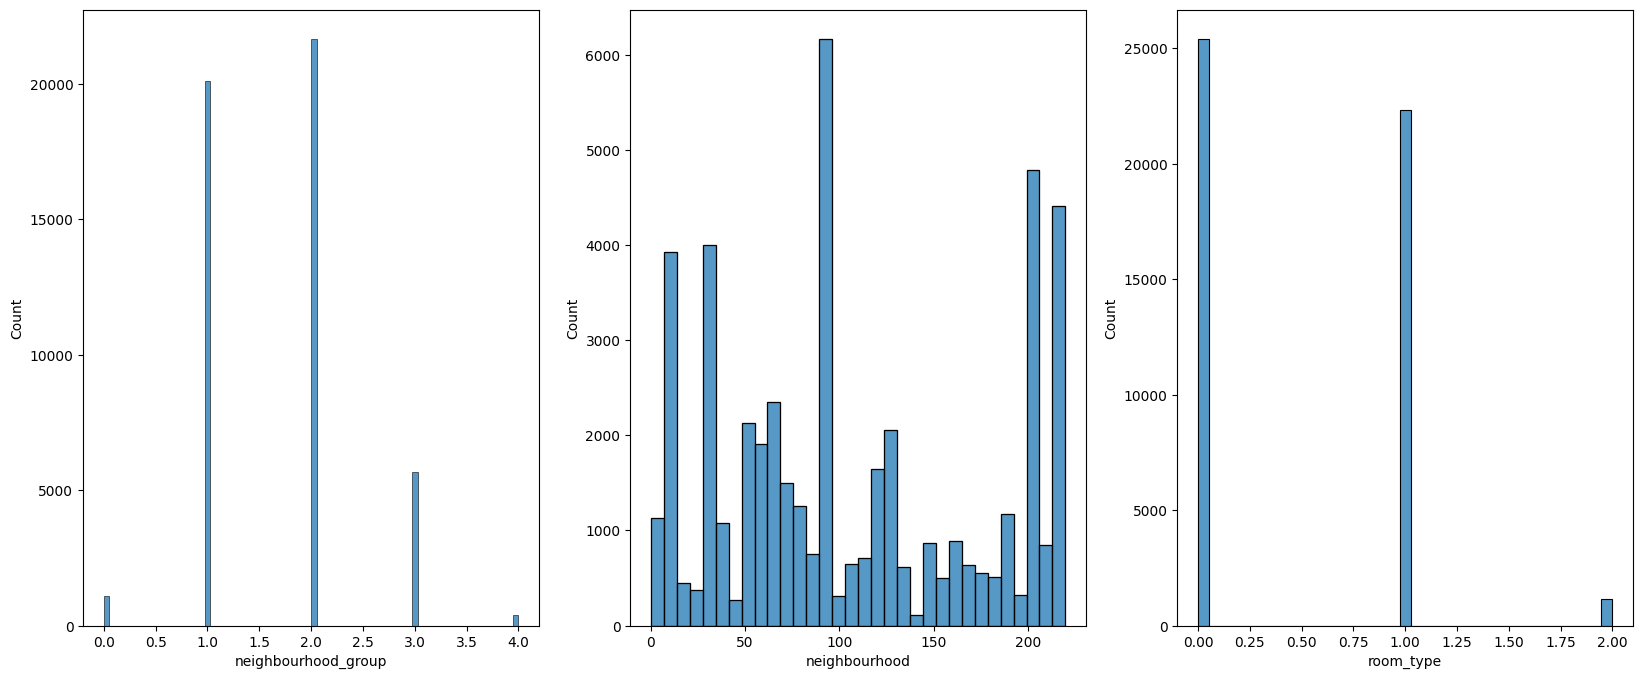

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8))
sns.histplot(data["neighbourhood_group"], ax=axes[0])
sns.histplot(data["neighbourhood"], ax=axes[1])
sns.histplot(data["room_type"], ax=axes[2])
plt.show()

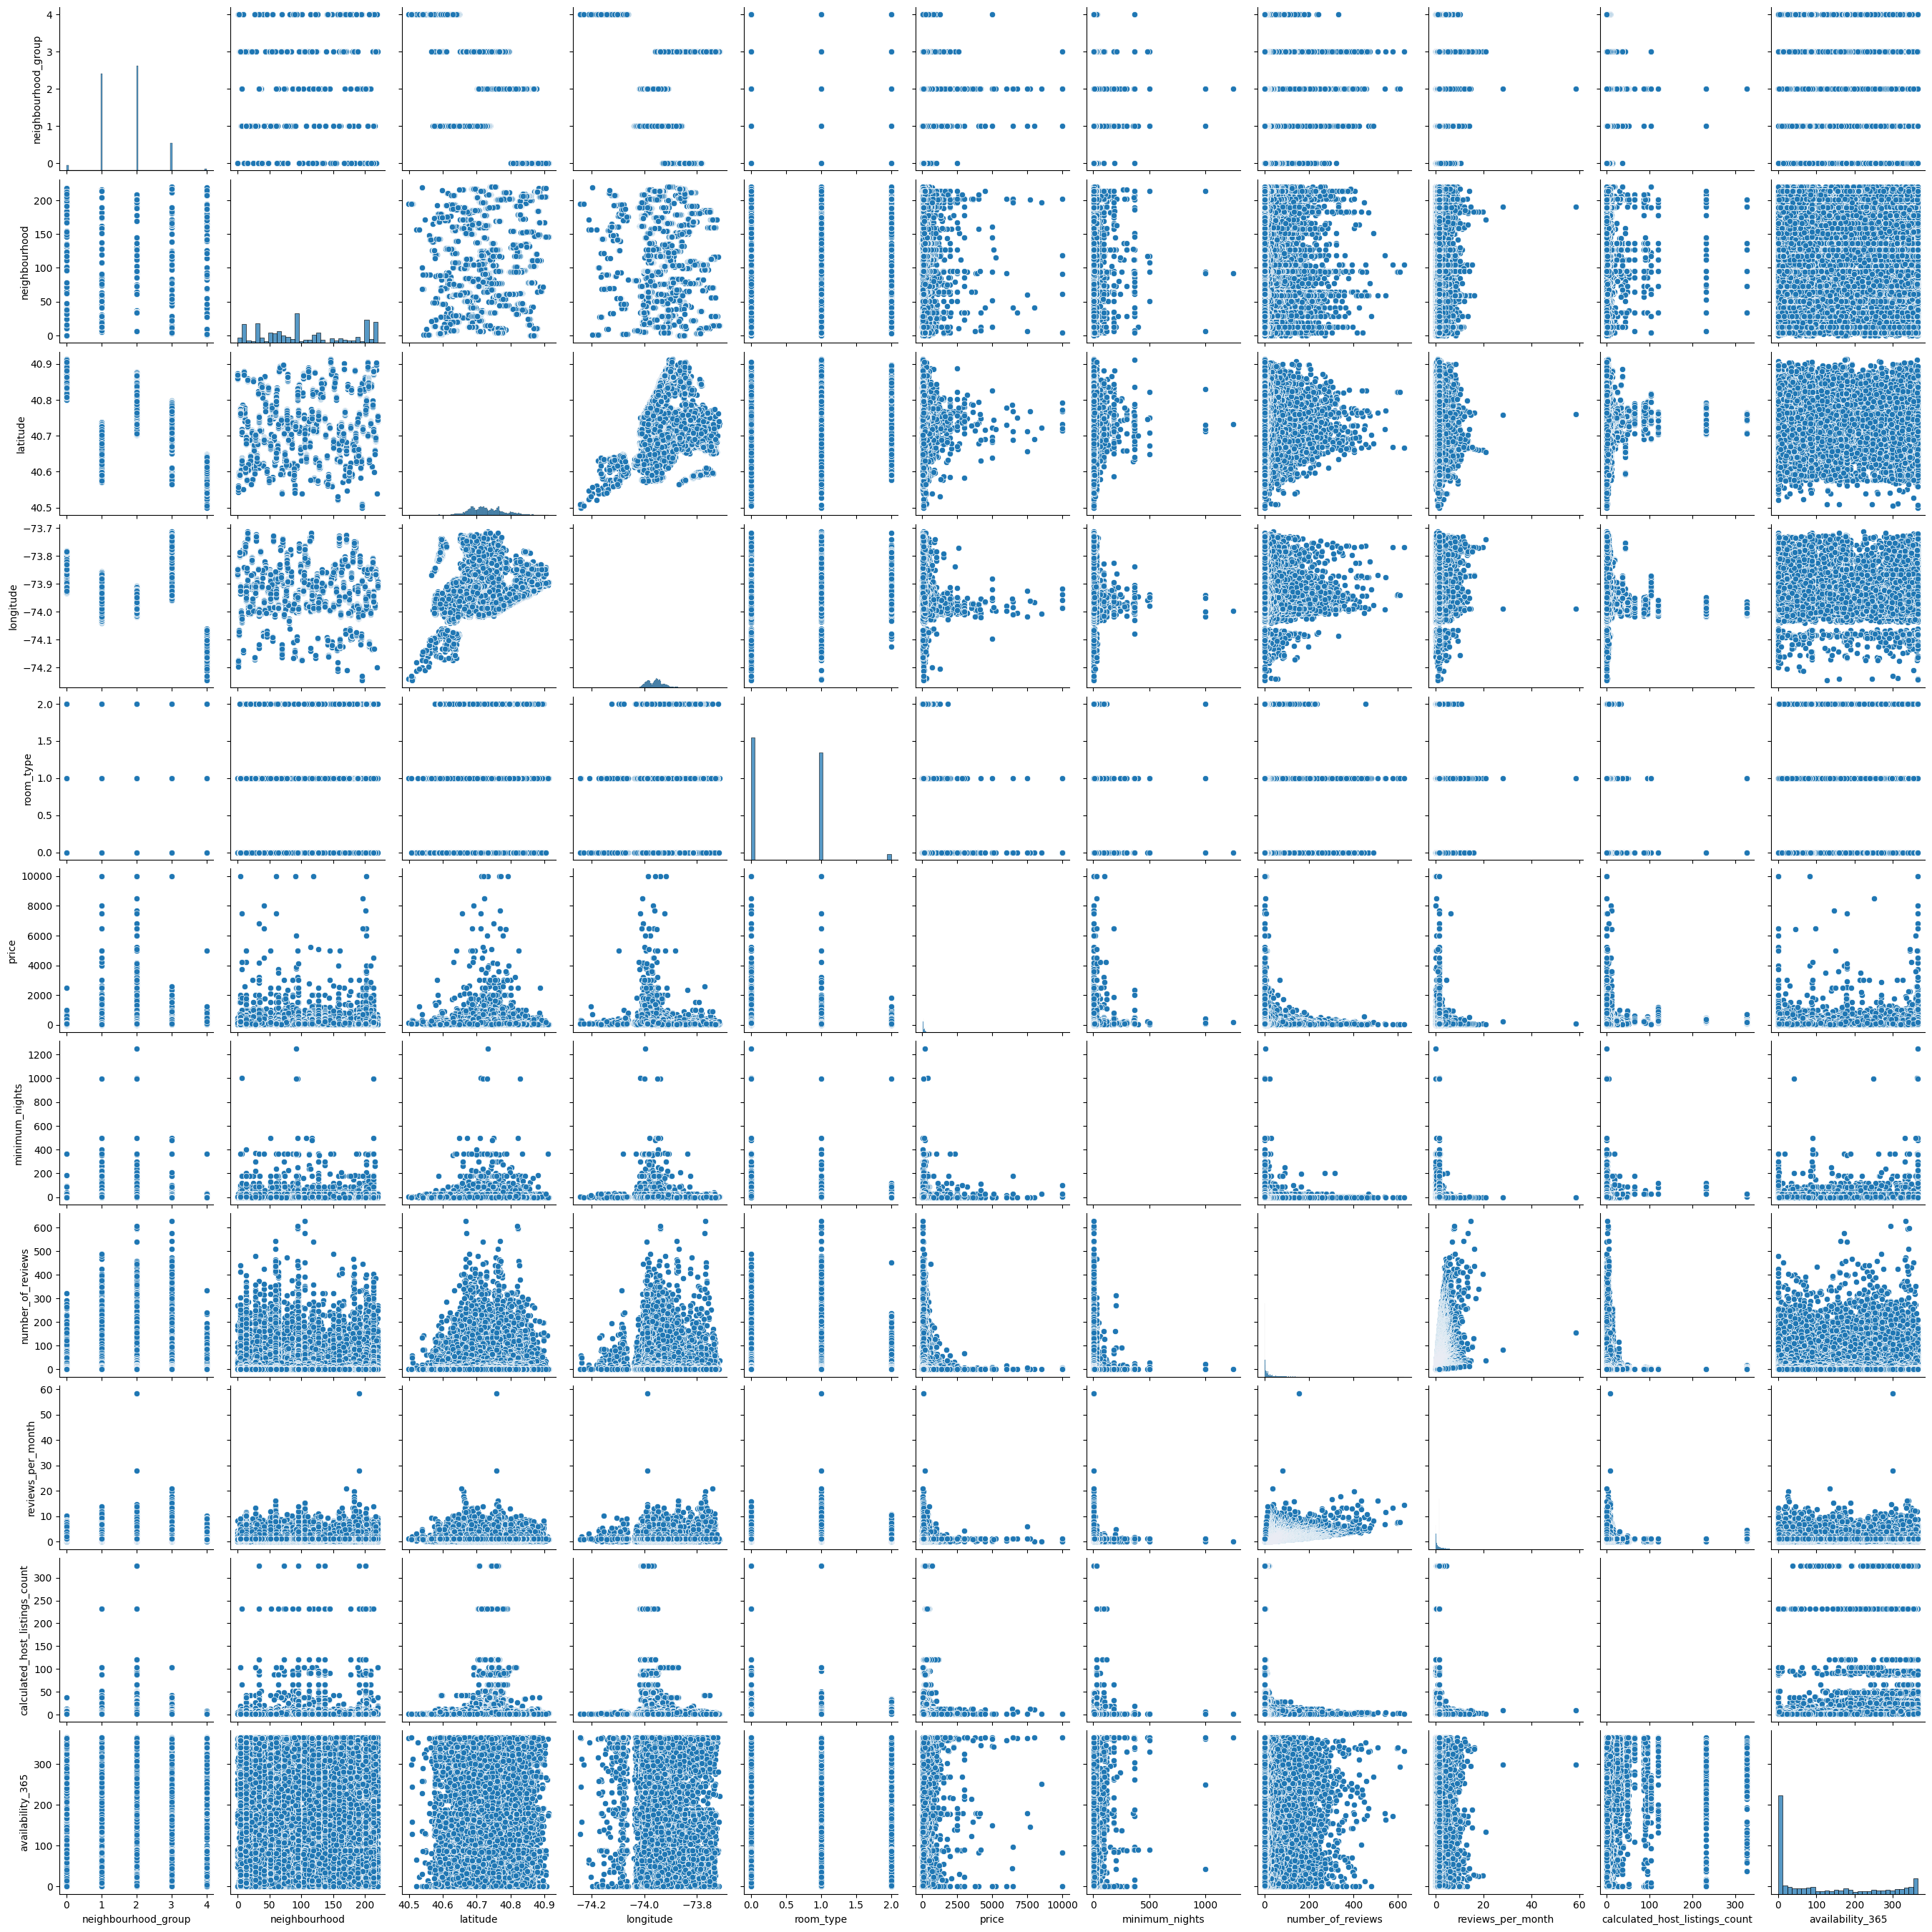

In [5]:
sns.pairplot(data)

Если мы посмотрим на тепловую карту, то увидим практически такую же картину.

Оказывается координаты сильной корреляцией не обладают. Максимальная корреляция на уровне ~0.6.

<Axes: >

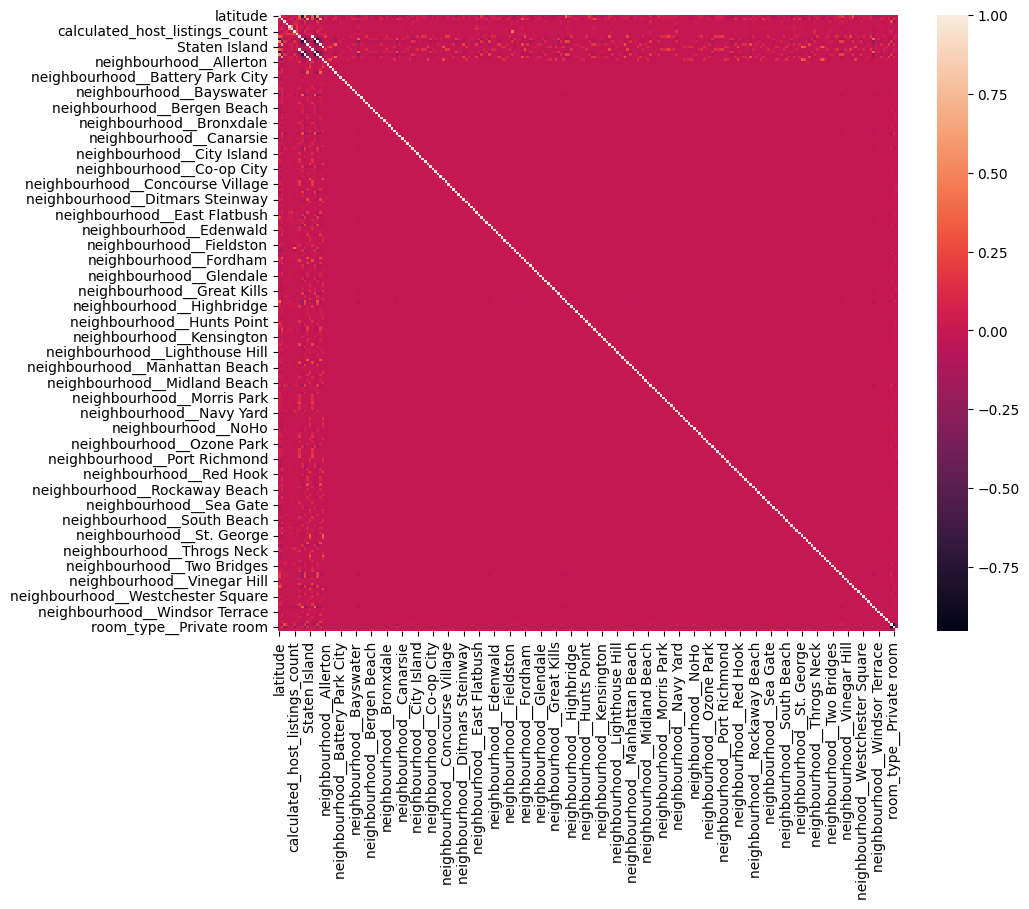

In [112]:
correlation_threshold = .85 # Значение корреляции, которые мы считаем сильным

correlated_columns = dict() # Колонки, которые коррелируют между собой

corr_data = data.corr()

for column in corr_data.columns:
    values_bigger_than_threshold = corr_data[column][corr_data[column] > correlation_threshold]
    correlated_columns[column] = list(values_bigger_than_threshold.index)
    correlated_columns[column].remove(column)
    
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data)

Из графика ниже мы видим, что существуют районы, где цена сильно выше. Это так же подтверждается координатами.

По категории комнат распределение более равномерное, но у типа 1 и 0 так же есть особо дорогие экземпляры.

Имущество с меньшим минимальным количеством ночей чаще бывает дороже.

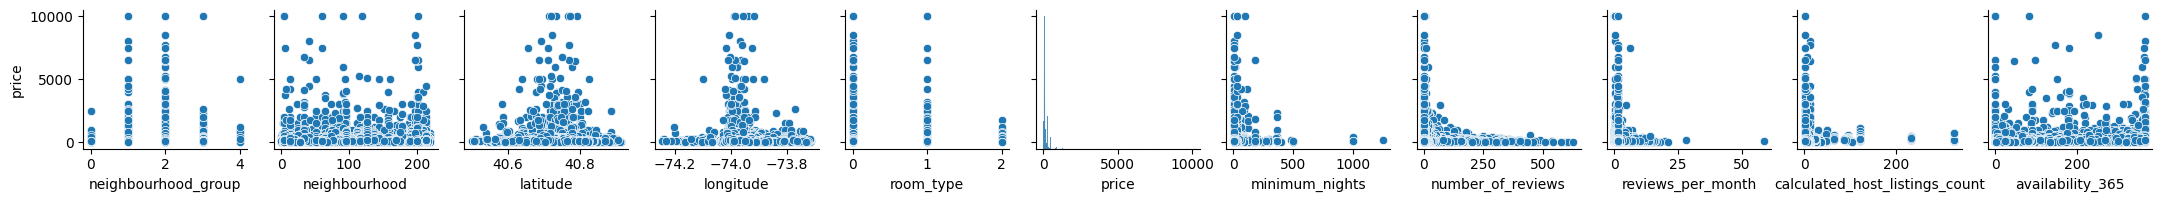

In [48]:
sns.pairplot(data, y_vars=["price"], height=2)

Заменим аномалии на средние значения и взгляем еще раз на графики.

После замены аномалий графики стали более четкими и квадратными.

На тепловой карте стали более выражены корреляции.

В частности стала более заметна корреляция между районом и широтой.

Однако, нет ни одного параметра, который явно бы влиял на цену недвижимости. Даже такой параметр как тип комнаты особенно не влияет на цену.

In [9]:
import numpy as np
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outliers = (data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))
cleaned_data = data.copy()
cleaned_data[outliers] = np.mean(data[~outliers])

/tmp/ipykernel_16870/3294238790.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30.67034464730691' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cleaned_data[outliers] = np.mean(data[~outliers])


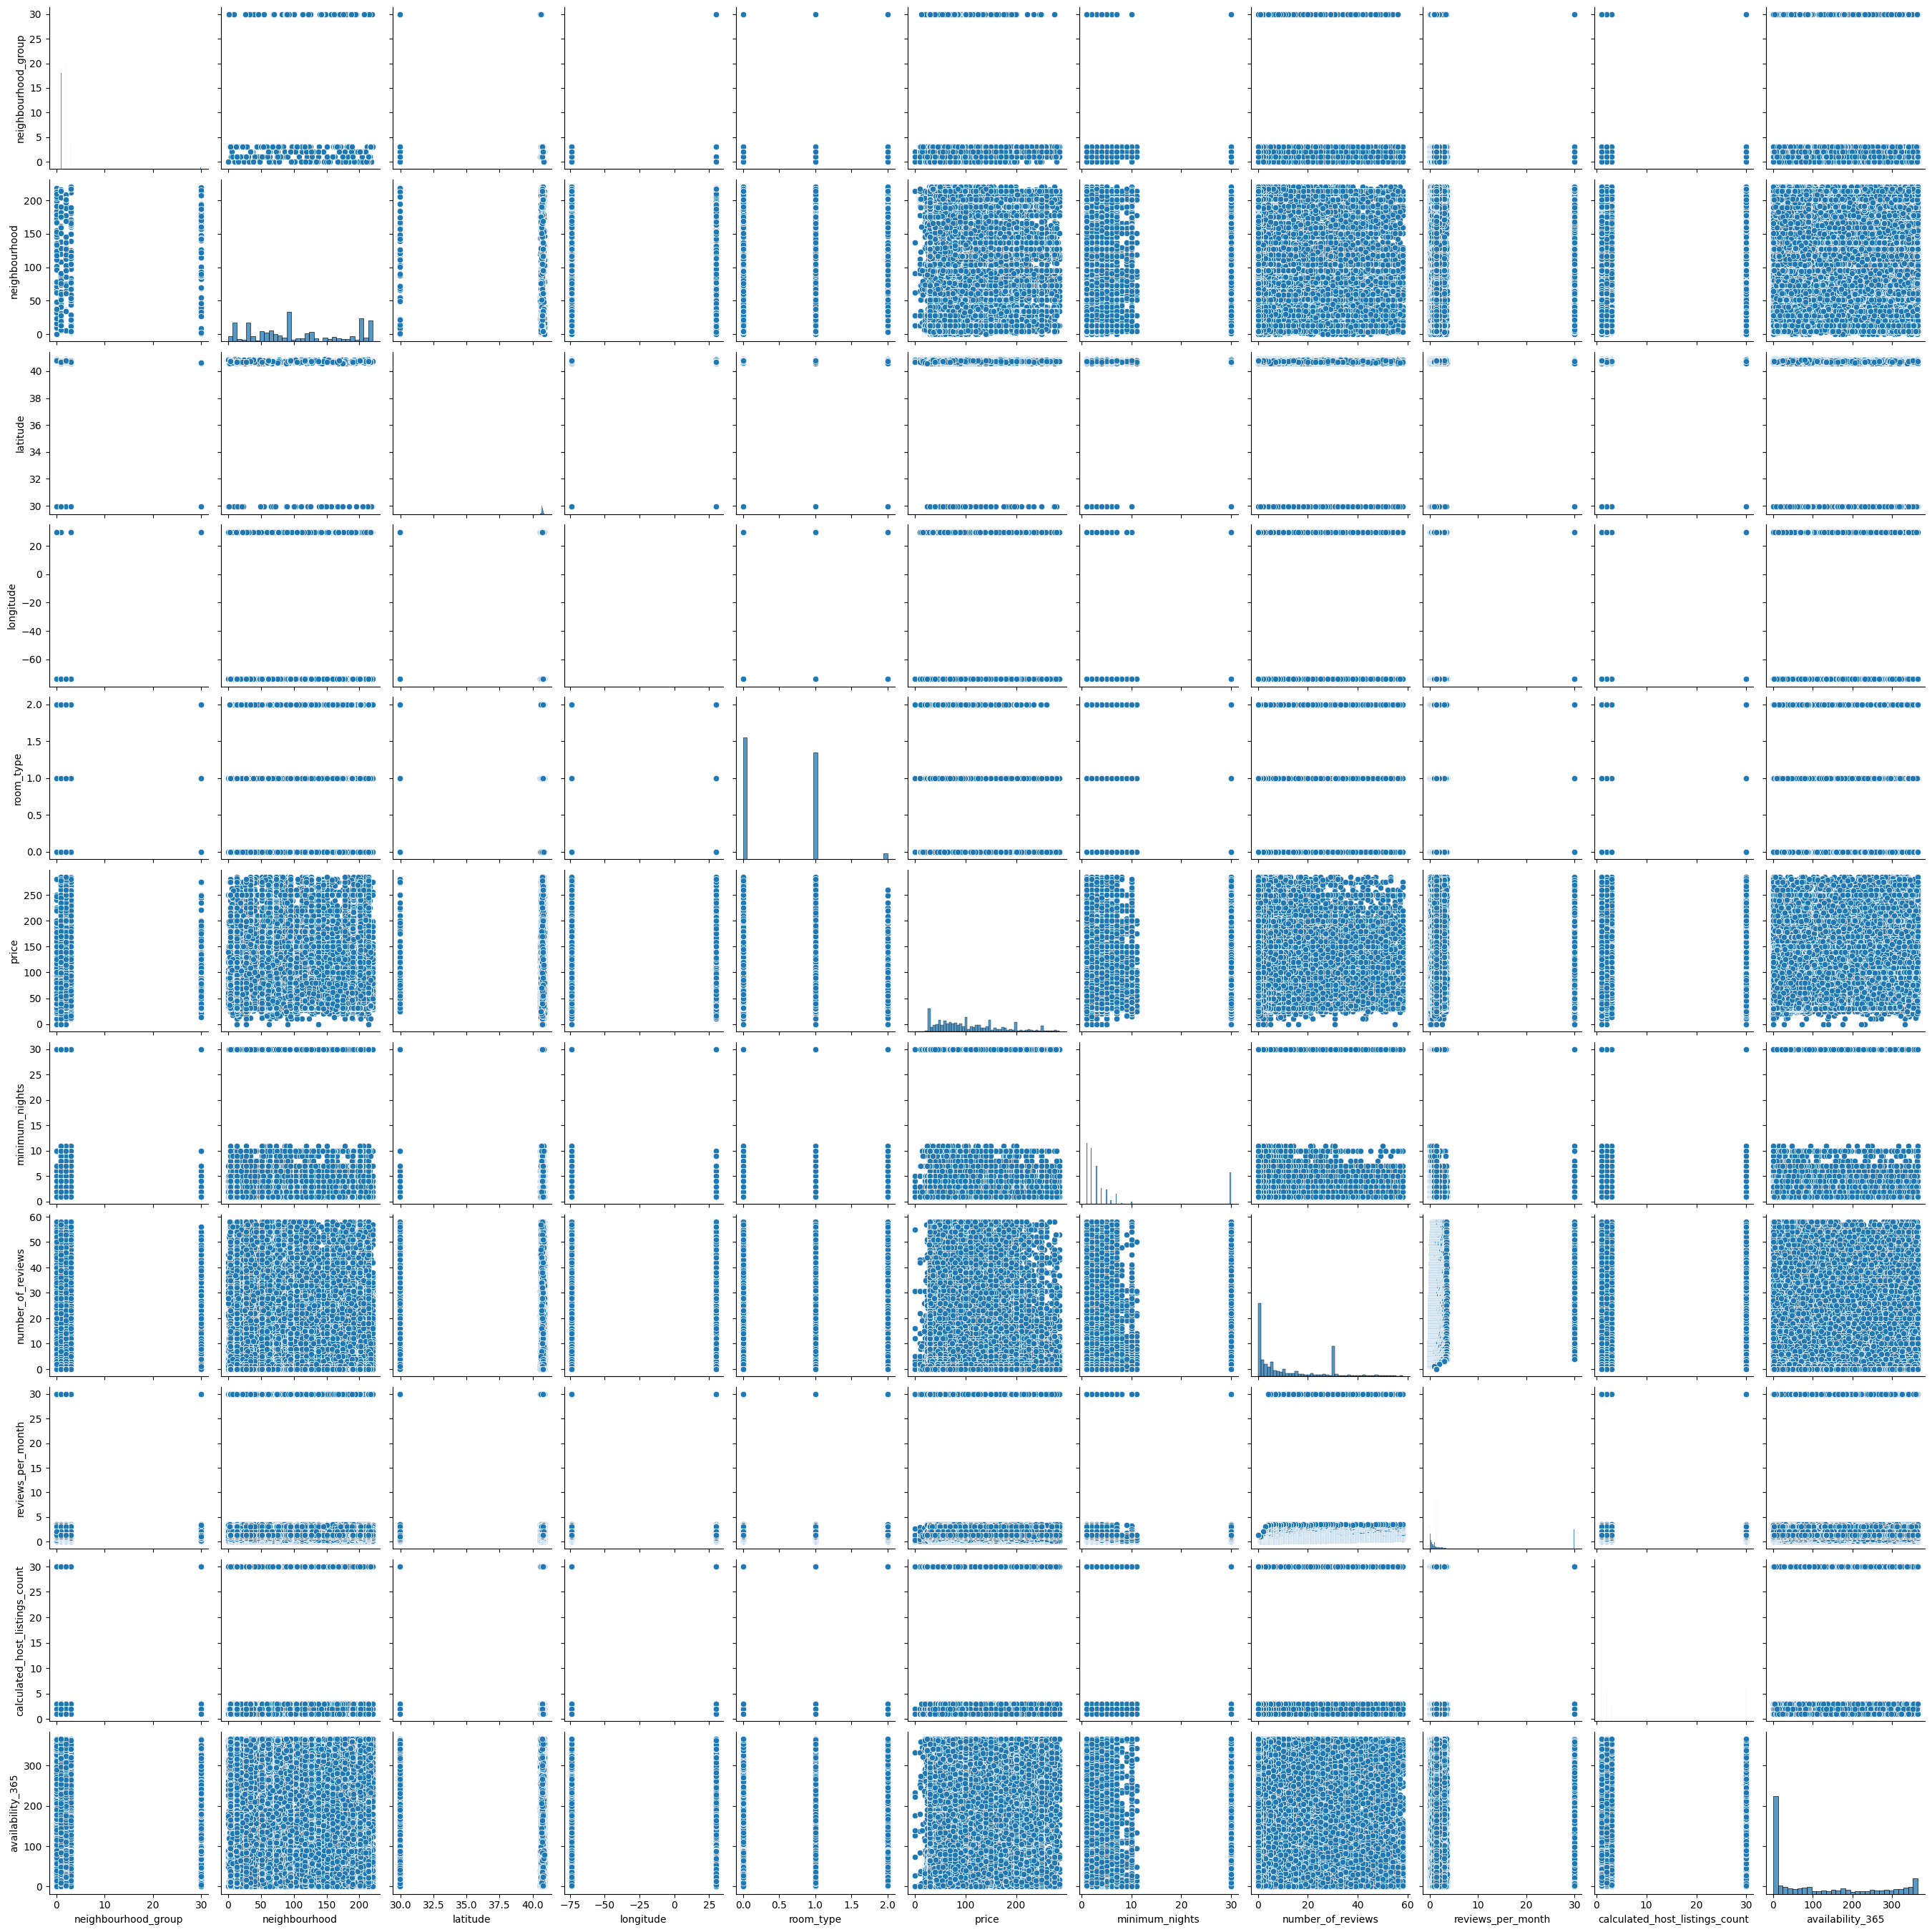

In [ ]:
sns.pairplot(cleaned_data)

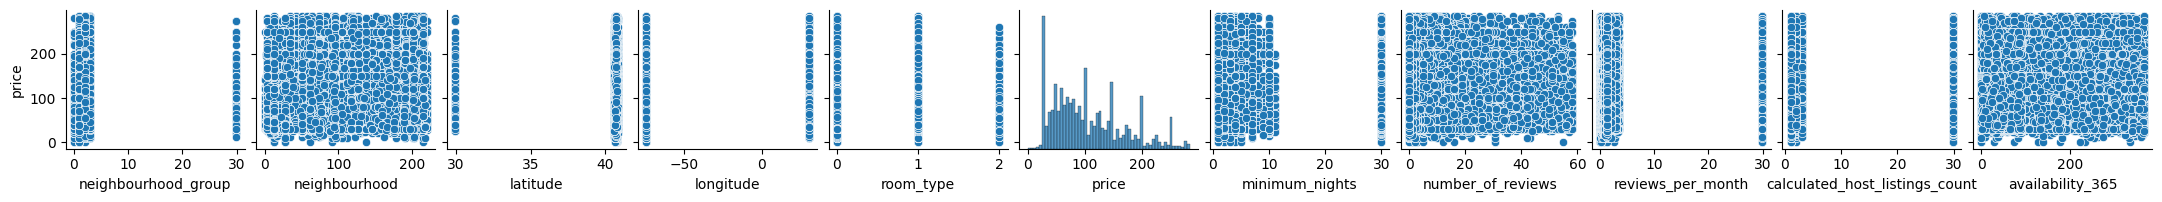

In [ ]:
sns.pairplot(cleaned_data, y_vars=["price"], height=2)

<Axes: >

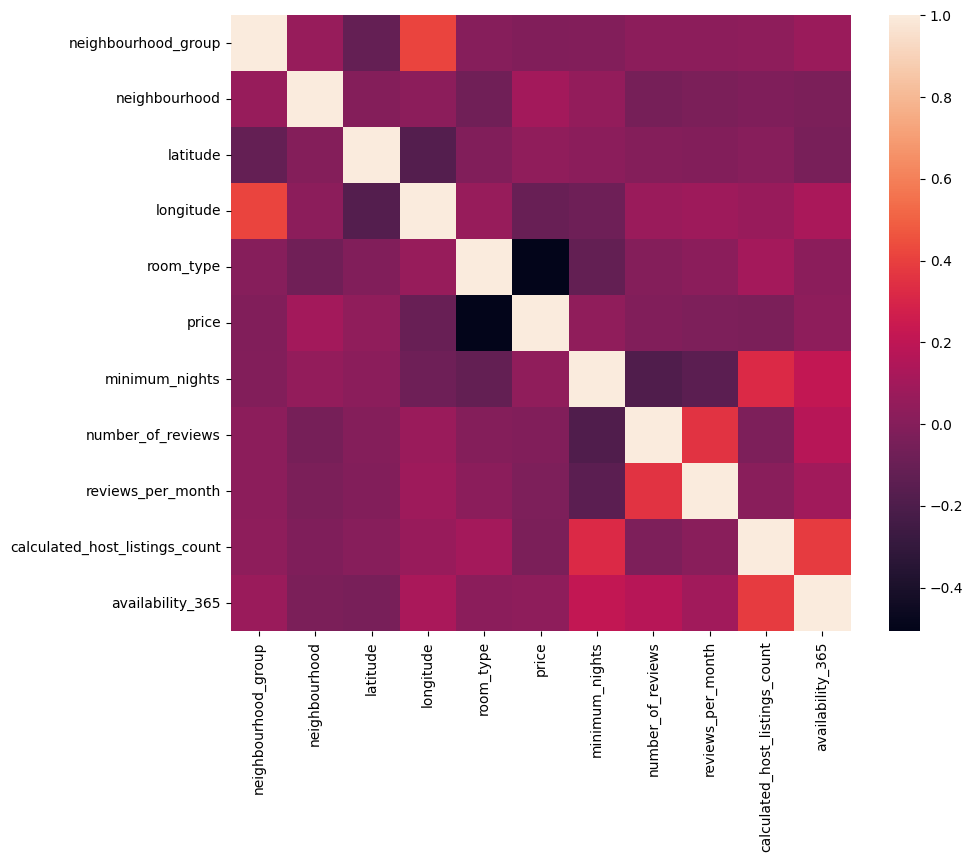

In [10]:
correlation_threshold = .85 # Значение корреляции, которые мы считаем сильным

correlated_columns = dict() # Колонки, которые коррелируют между собой

corr_data = cleaned_data.corr()

for column in corr_data.columns:
    values_bigger_than_threshold = corr_data[column][corr_data[column] > correlation_threshold]
    correlated_columns[column] = list(values_bigger_than_threshold.index)
    correlated_columns[column].remove(column)
    
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data)

Попробуем построить различные модели и проверим их, а затем прошкалируем данные и повторим операцию.

Задачи:
- попробовать различные модели
- попробовать различные скейлеры
- попробовать ансамбли моделей

Начнем с моделей:
- линейная регрессия
- дерево решений для задач регрессии

In [113]:
def scores(predict, test):
    return r2_score(predict, test), mean_absolute_error(predict, test), mean_squared_error(predict, test)

def fit_and_predict(model, train_X, train_y, test_X):
    model.fit(train_X, train_y)
    return model.predict(test_X)

def learn_models_and_get_result(X, y):
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)
    result = dict()
    result["LinearRegression"] = scores(fit_and_predict(LinearRegression(), train_X, train_y, test_X), test_y)
    result["Ridge"] = scores(fit_and_predict(Ridge(), train_X, train_y, test_X), test_y)
    result["DecisionTreeRegressor"] = scores(fit_and_predict(DecisionTreeRegressor(random_state=42), train_X, train_y, test_X), test_y)
    result["LinearBaggingRegressor"] = scores(fit_and_predict(BaggingRegressor(estimator=LinearRegression(), n_estimators=100, max_samples=0.8, random_state=42), train_X, train_y, test_X), test_y)
    result["DecisionTreeBaggingRegressor"] = scores(fit_and_predict(BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42), n_estimators=100, max_samples=0.8, random_state=42), train_X, train_y, test_X), test_y)
    result["RandomForestRegressor"] = scores(fit_and_predict(RandomForestRegressor(n_estimators=100, max_samples=0.8, random_state=42), train_X, train_y, test_X), test_y)
    result["GradientBoostingRegressor"] = scores(fit_and_predict(GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42), train_X, train_y, test_X), test_y)
    return result

def print_results(results):
    for key, value in results.items():
        print(key, "=", value)

def scale_and_learn(scaler, data):
    X = data.drop("price", axis=1)
    y = data["price"]
    scaler.fit(X)
    X = scaler.transform(X)
    return learn_models_and_get_result(X, y)

In [114]:
X = data.drop("price", axis=1)
y = data["price"]
print_results(learn_models_and_get_result(X, y))

LinearRegression = (-3.930869907092708, 69.23111412440177, 34286.97916600525)
Ridge = (-3.9785663485002383, 69.1380304692035, 34264.7698114945)
DecisionTreeRegressor = (-0.11077158246731478, 85.19006067216579, 94205.59854114118)
LinearBaggingRegressor = (-3.9170778965887143, 69.16742564777566, 34276.37146275432)
DecisionTreeBaggingRegressor = (-0.7904827739159008, 64.75034781804193, 36167.86031798836)
RandomForestRegressor = (-0.8007916513701752, 64.54207822456817, 35821.64495831755)
GradientBoostingRegressor = (-2.7638966220994385, 64.35568758855663, 32689.995921873546)


In [115]:
print_results(scale_and_learn(MinMaxScaler(), data))

LinearRegression = (-3.9308699070932756, 69.23111412439624, 34286.97916600472)
Ridge = (-3.9758823264053573, 69.12083110502711, 34259.00741117547)
DecisionTreeRegressor = (-0.10231443137597296, 85.89065375962915, 100741.79057877156)
LinearBaggingRegressor = (-3.917077896588488, 69.1674256477772, 34276.37146275434)
DecisionTreeBaggingRegressor = (-0.7891034313480623, 64.75740215030726, 36201.8175118481)
RandomForestRegressor = (-0.7988267343409254, 64.55861718427911, 35863.14843346923)
GradientBoostingRegressor = (-2.7637831660268346, 64.35618355194093, 32689.683222835127)


In [116]:
print_results(scale_and_learn(StandardScaler(), data))

LinearRegression = (-3.92840809985504, 69.23123808862756, 34284.21756517322)
Ridge = (-3.928616638105665, 69.2306758062174, 34284.20150219444)
DecisionTreeRegressor = (-0.11104286040519451, 85.2201240711705, 94215.79630513328)
LinearBaggingRegressor = (-3.91366057361559, 69.17510999872567, 34270.002214623295)
DecisionTreeBaggingRegressor = (-0.7940929165653536, 64.70280265477246, 36186.60911239249)
RandomForestRegressor = (-0.8016901818920585, 64.49538724358787, 35836.59504885996)
GradientBoostingRegressor = (-2.763849356278268, 64.3554784272569, 32689.661836375773)


In [117]:
print_results(scale_and_learn(RobustScaler(), data))

LinearRegression = (-3.93086990709335, 69.23111412439587, 34286.97916600467)
Ridge = (-3.9690335226434303, 69.14648186477012, 34257.03730581899)
DecisionTreeRegressor = (-0.10228143605356332, 85.89147181130275, 100760.43356738701)
LinearBaggingRegressor = (-3.9170778965884985, 69.16742564777722, 34276.37146275434)
DecisionTreeBaggingRegressor = (-0.79171944370624, 64.72316327921857, 36148.84052868926)
RandomForestRegressor = (-0.8021108006332052, 64.50455214917108, 35794.83221588794)
GradientBoostingRegressor = (-2.763849938892103, 64.35784202493639, 32689.902634062448)


Лучший alpha: 10.0
Лучший alpha: 2.6174163132272565
Количество ненулевых коэффициентов: 7
Лучший alpha: 5.234832626454513
Лучший l1_ratio: 0.5


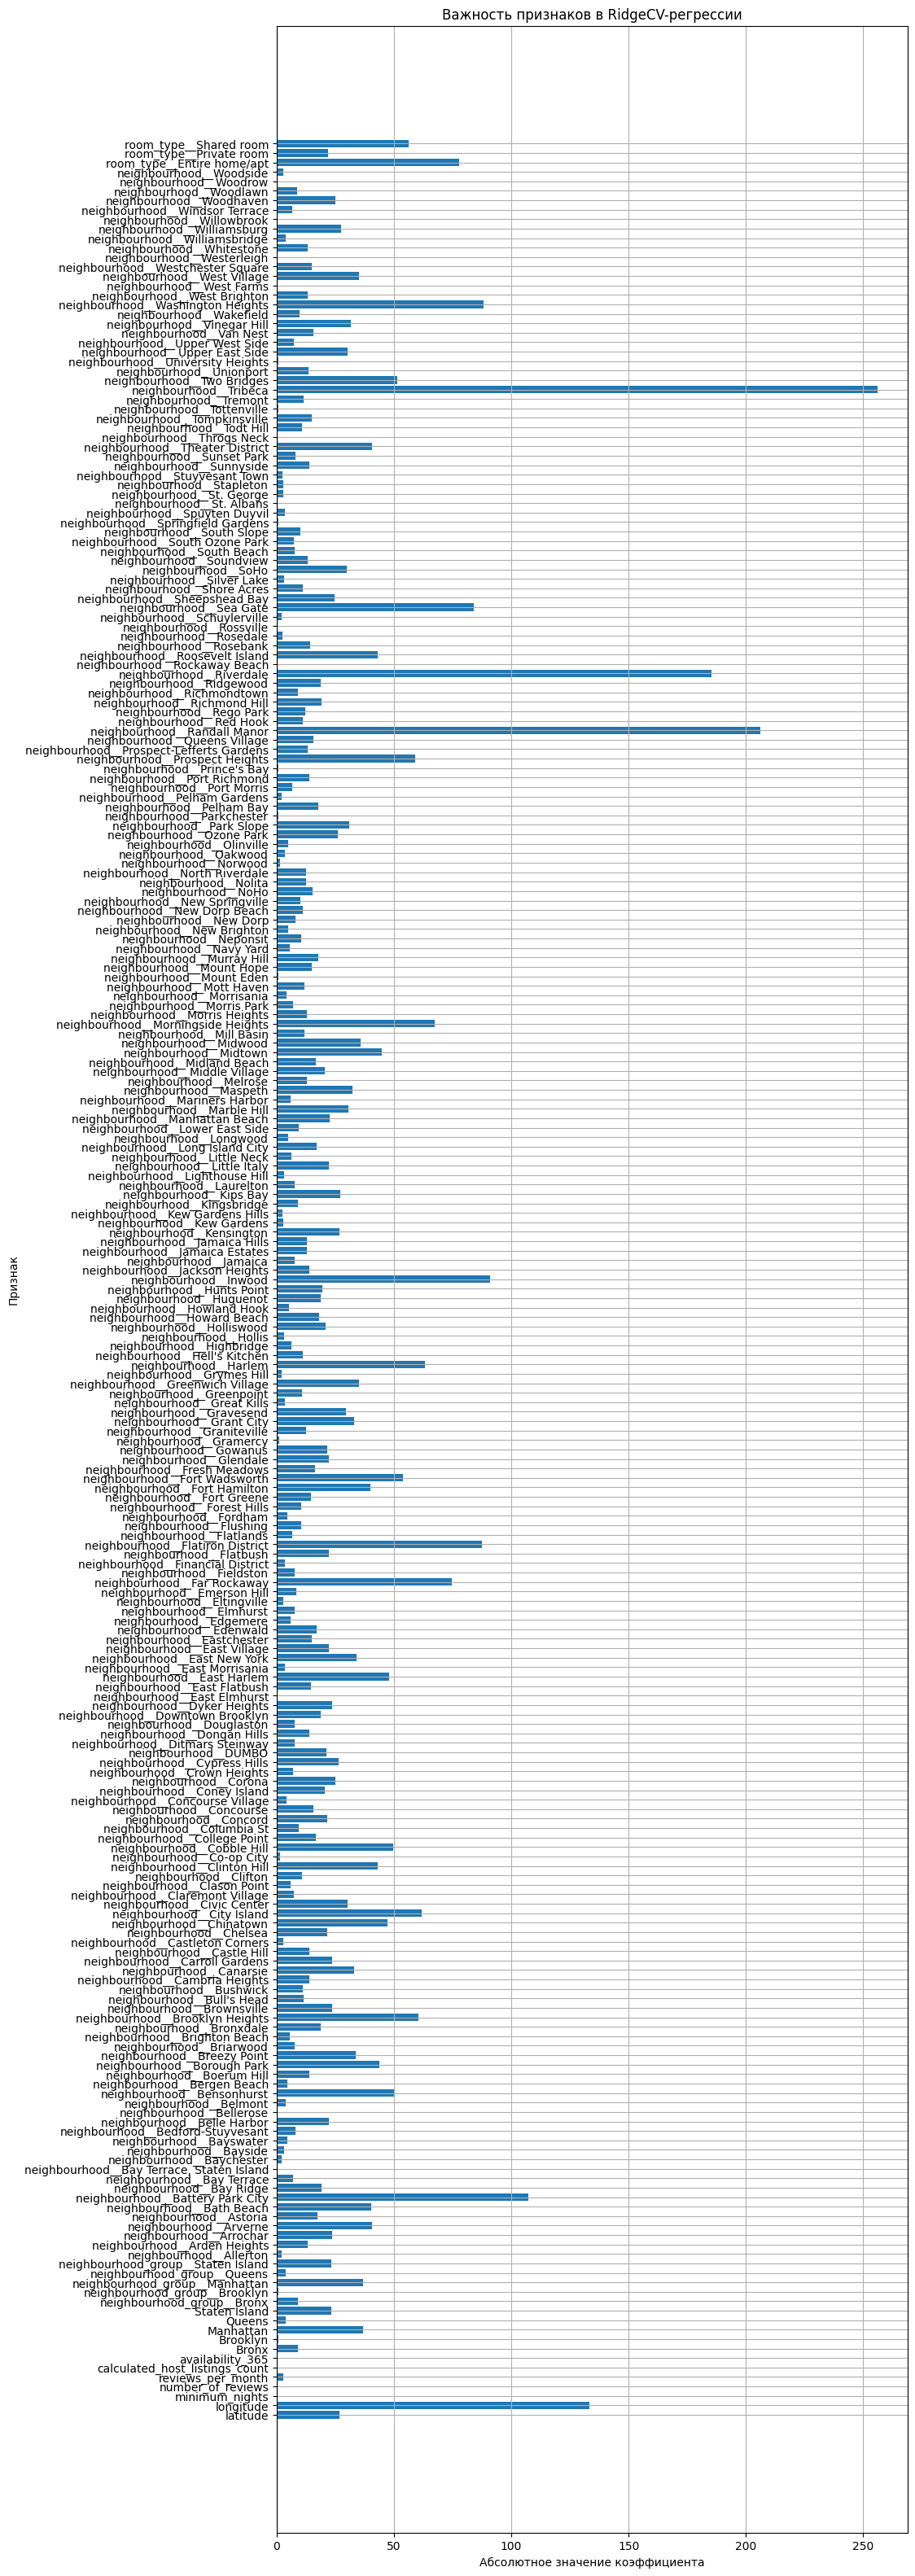

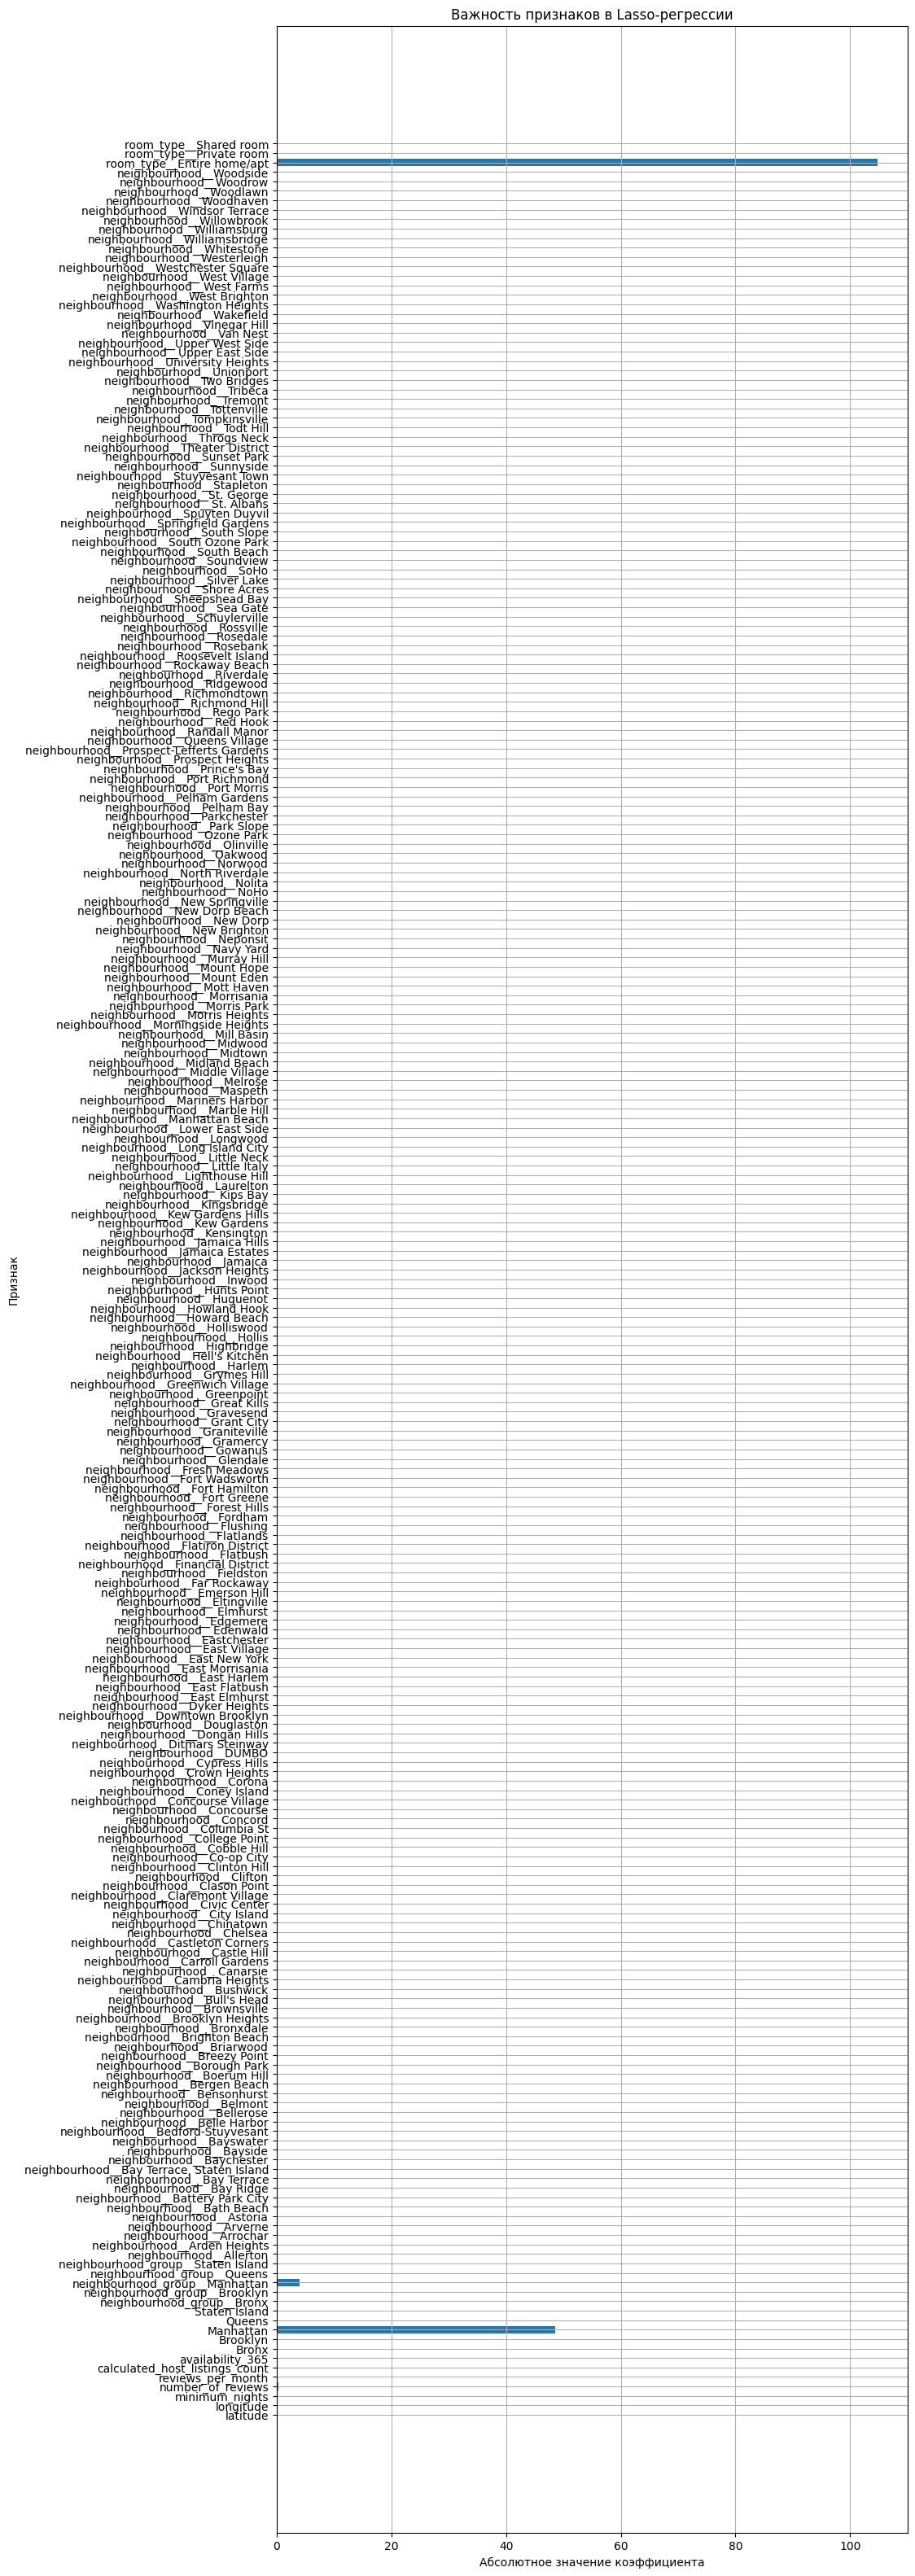

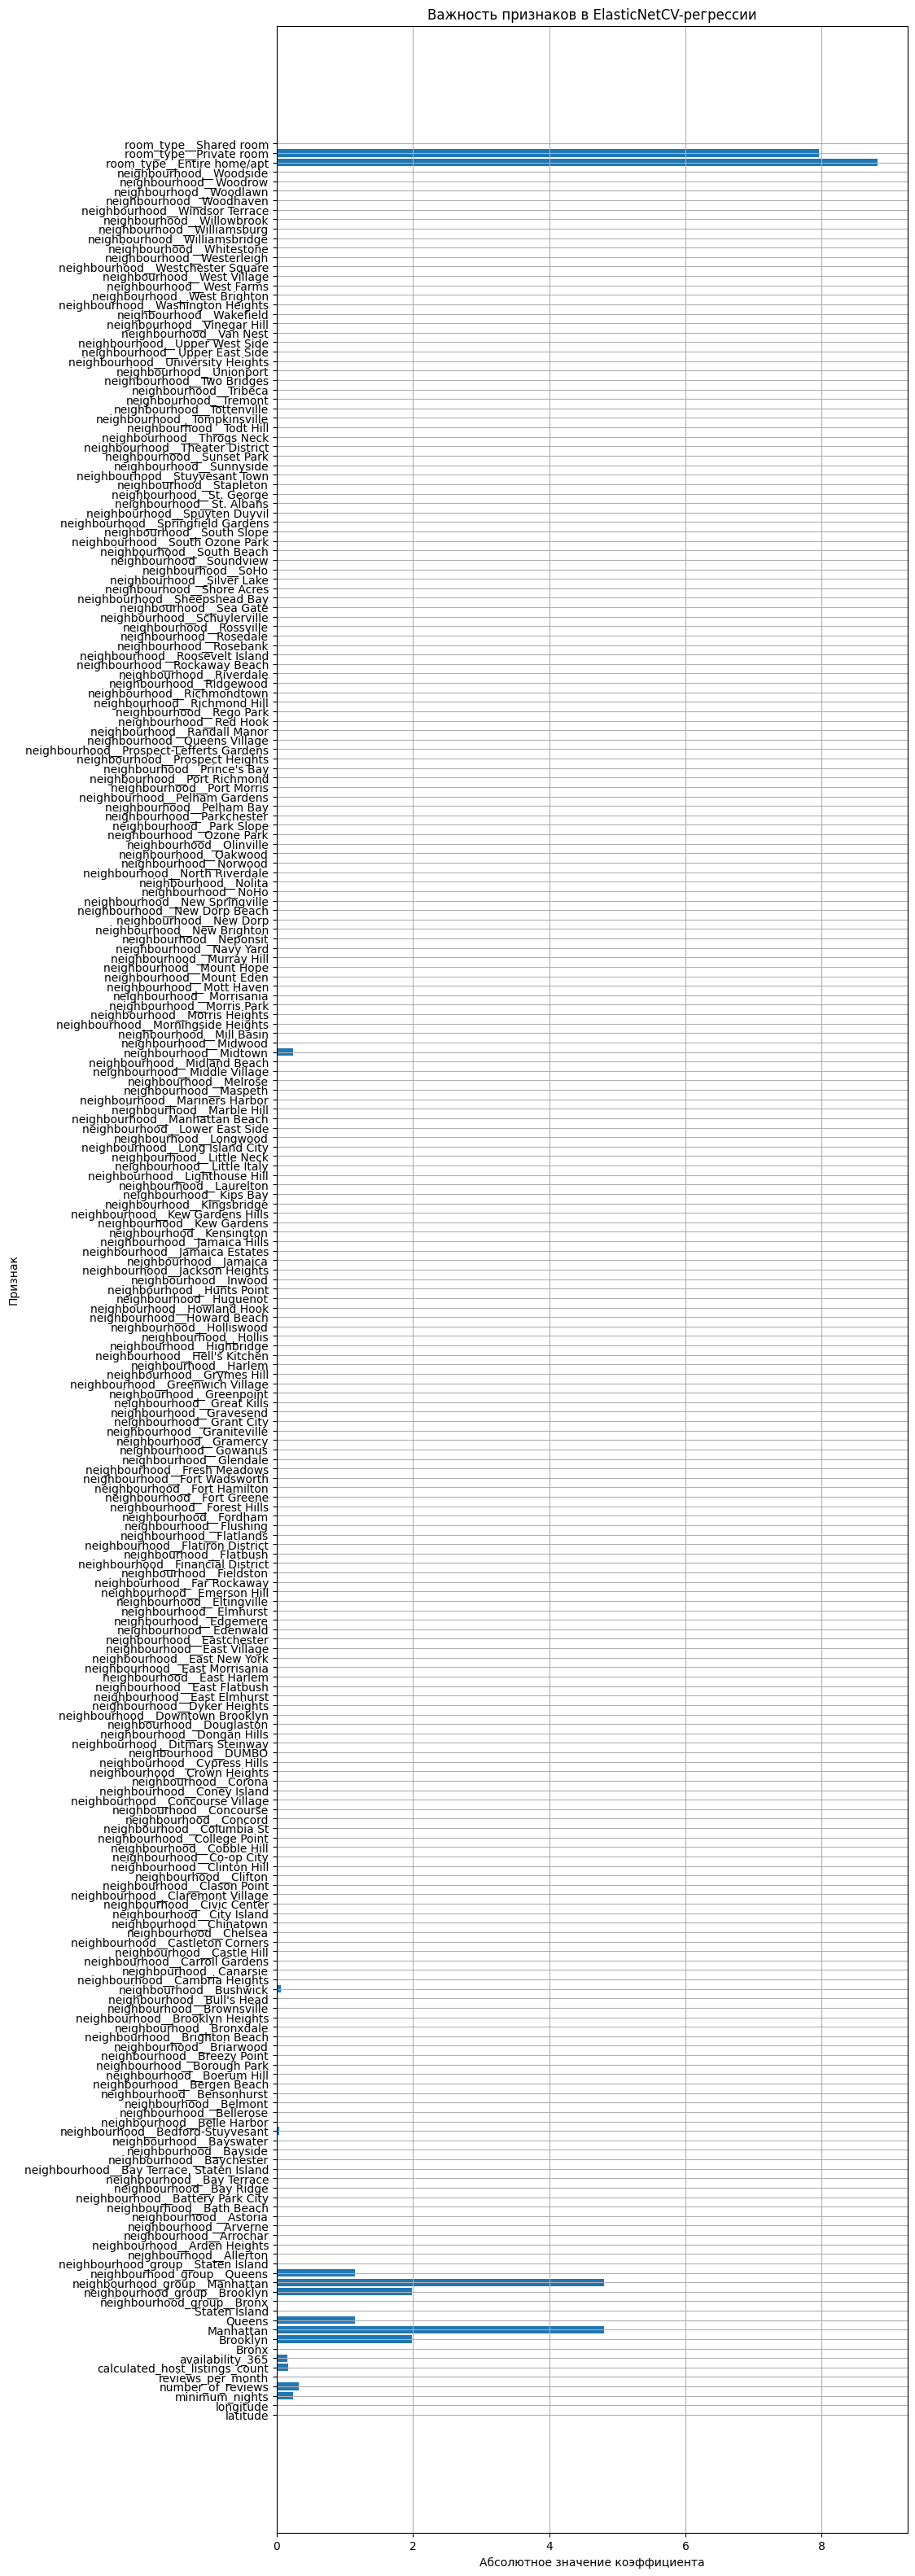

In [124]:
X = data.drop("price", axis=1)
y = data["price"]
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

ridge_cv = RidgeCV()
scores(fit_and_predict(ridge_cv, train_X, train_y, test_X), test_y)
lasso_cv = LassoCV()
scores(fit_and_predict(lasso_cv, train_X, train_y, test_X), test_y)
elastic_cv = ElasticNetCV()
scores(fit_and_predict(elastic_cv, train_X, train_y, test_X), test_y)

print("Лучший alpha:", ridge_cv.alpha_)
print("Лучший alpha:", lasso_cv.alpha_)
print("Количество ненулевых коэффициентов:", sum(lasso_cv.coef_ != 0))
print("Лучший alpha:", elastic_cv.alpha_)
print("Лучший l1_ratio:", elastic_cv.l1_ratio_)

size = (10, 40)

plt.figure(figsize=size)
plt.barh(X.columns, np.abs(ridge_cv.coef_))
plt.title("Важность признаков в RidgeCV-регрессии")
plt.xlabel("Абсолютное значение коэффициента")
plt.ylabel("Признак")
plt.grid(True)
plt.show()


plt.figure(figsize=size)
plt.barh(X.columns, np.abs(lasso_cv.coef_))
plt.title("Важность признаков в Lasso-регрессии")
plt.xlabel("Абсолютное значение коэффициента")
plt.ylabel("Признак")
plt.grid(True)
plt.show()


plt.figure(figsize=size)
plt.barh(X.columns, np.abs(elastic_cv.coef_))
plt.title("Важность признаков в ElasticNetCV-регрессии")
plt.xlabel("Абсолютное значение коэффициента")
plt.ylabel("Признак")
plt.grid(True)
plt.show()